In [1]:
import numpy as np;
from sklearn.datasets import make_blobs;
import matplotlib.pyplot as plt

In [2]:
X, _ = make_blobs(n_samples=300, n_features=2, centers = 4, random_state=42);

In [3]:
print(X[:10])

[[ -9.29768866   6.47367855]
 [ -9.69874112   6.93896737]
 [ -1.68665271   7.79344248]
 [ -7.09730839  -5.78133274]
 [-10.87645229   6.3154366 ]
 [ -6.02196757  -7.04004812]
 [  4.81305976   2.35848706]
 [ -6.46669574  -7.44383415]
 [ -2.98837186   8.82862715]
 [  3.44857534   2.62972329]]


In [4]:
k = 4;
max_itr = 100;

In [5]:
indices = np.random.choice(X.shape[0], k, replace=False);
#print(indices);
centroids = X[indices]
print (centroids)

[[-2.67048333  9.41833699]
 [ 4.91656964  2.80035293]
 [-7.77804186 -6.38819042]
 [-7.39349411 -7.93932312]]


In [6]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

In [7]:
euclidean_distance(X[0], centroids[0])

np.float64(7.251955853078842)

In [8]:
def closest_centroid(sample, centroids):
    distances = [euclidean_distance(sample, point) for point in centroids];
    closest_index = np.argmin(distances);
    #print(distances)
    return closest_index;

In [9]:
closest_centroid(X[0], centroids)

np.int64(0)

In [10]:
def create_clusters(X, centroids):
    clusters = [[] for _ in range(k)];

    for idx, val in enumerate(X):
        centroid_idx = closest_centroid(val, centroids);
        clusters[centroid_idx].append(idx);

    return clusters;
        
        
    

In [11]:
clusters = create_clusters(X, centroids);
len(clusters)

4

In [12]:
def get_centroids(X, clusters):
    newcentroids = np.zeros((len(clusters), X.shape[1]));

    for cluster_idx, cluster in enumerate(clusters):
        cluster_mean = np.mean(X[cluster], axis=0)
        newcentroids[cluster_idx] = cluster_mean;
    
    return newcentroids;

In [13]:
centroids = get_centroids(X, clusters);
print (centroids)

[[-5.75060003  8.08498739]
 [ 4.7182049   2.04179676]
 [-7.18131472 -6.15474346]
 [-6.47395796 -7.52443405]]


In [14]:
def plot(X, clusters, centroids):
        fig, ax = plt.subplots(figsize=(12, 8))

        for i, index in enumerate(clusters):
            point = X[index].T
            ax.scatter(*point)

        for point in centroids:
            ax.scatter(*point, marker="x", color='black', linewidth=2)

        plt.show()

In [15]:
def is_converged(centroids_old, centroids):
    distances = [euclidean_distance(centroids_old[i], centroids[i]) for i in range(len(centroids))]
    return sum(distances) == 0


In [16]:
def fit(X, centroids):
    for _ in range(max_itr):
        clusters = create_clusters(X, centroids);
        oldcentroids = centroids;
        centroids = get_centroids(X, clusters);
        if is_converged(oldcentroids, centroids):
            break;
        
        
        

In [17]:
fit(X, centroids)

In [18]:
print (clusters);
print (centroids)

[[0, 1, 2, 4, 8, 10, 12, 13, 14, 15, 16, 18, 19, 21, 23, 24, 25, 26, 30, 32, 34, 35, 36, 38, 41, 42, 44, 45, 46, 48, 51, 53, 56, 59, 60, 63, 69, 72, 74, 75, 78, 80, 81, 82, 83, 85, 86, 90, 91, 92, 93, 94, 95, 97, 98, 99, 103, 104, 105, 106, 107, 109, 111, 112, 113, 114, 116, 118, 122, 123, 125, 126, 127, 128, 131, 132, 133, 134, 137, 138, 140, 143, 149, 150, 151, 154, 157, 158, 160, 161, 163, 165, 167, 168, 169, 170, 171, 180, 181, 182, 185, 187, 193, 199, 200, 201, 204, 207, 209, 210, 214, 216, 217, 218, 219, 220, 222, 226, 227, 231, 232, 236, 238, 239, 240, 244, 248, 250, 252, 255, 257, 258, 259, 261, 262, 263, 269, 270, 274, 275, 277, 278, 284, 290, 293, 294, 295, 297, 298, 299], [6, 9, 11, 17, 20, 29, 31, 33, 40, 47, 49, 55, 57, 58, 61, 62, 73, 87, 88, 89, 100, 101, 102, 110, 115, 130, 135, 136, 141, 144, 145, 146, 147, 152, 155, 159, 164, 173, 174, 177, 178, 183, 184, 188, 189, 194, 197, 198, 203, 213, 224, 225, 228, 229, 230, 234, 237, 243, 253, 256, 260, 265, 267, 268, 272, 273,

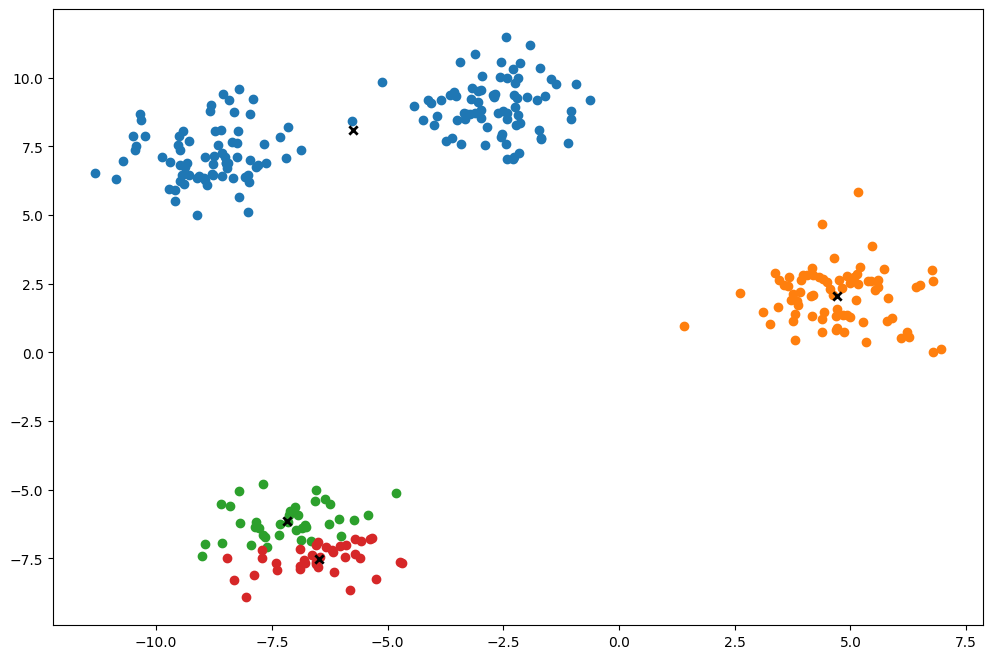

In [19]:
plot(X, clusters, centroids);